In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_path = "../data/LD2011_2014.txt"

In [3]:
client_id = 1                 # Set requested client

In [4]:
df = pd.read_csv(
    data_path,
    sep=";",
    decimal=",",
    usecols=[0, client_id]    # Get cols 0 and client_id (Load just the first client)
)

df.columns = ["timestamp", "load"]
df["timestamp"] = pd.to_datetime(df["timestamp"])

df.head()

,timestamp,load
0,2011-01-01 00:15:00,0.0
1,2011-01-01 00:30:00,0.0
2,2011-01-01 00:45:00,0.0
3,2011-01-01 01:00:00,0.0
4,2011-01-01 01:15:00,0.0


In [5]:
df = df.loc[df["timestamp"] >= "2012-01-01"].copy()

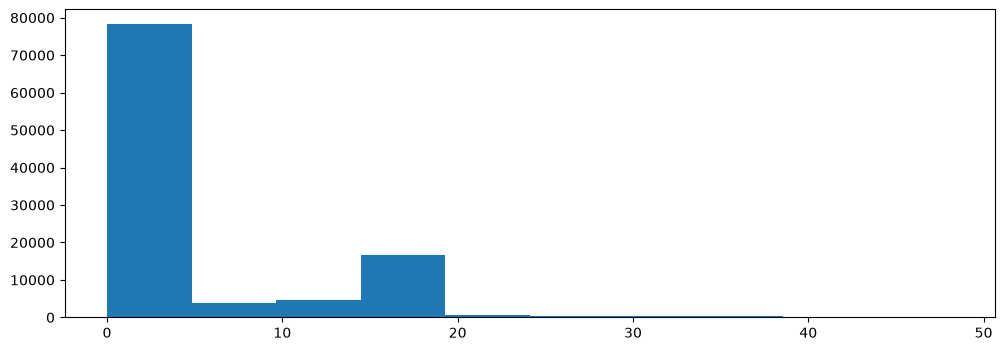

In [6]:
plt.figure(figsize=(12, 4))
plt.hist(df["load"])
plt.show()

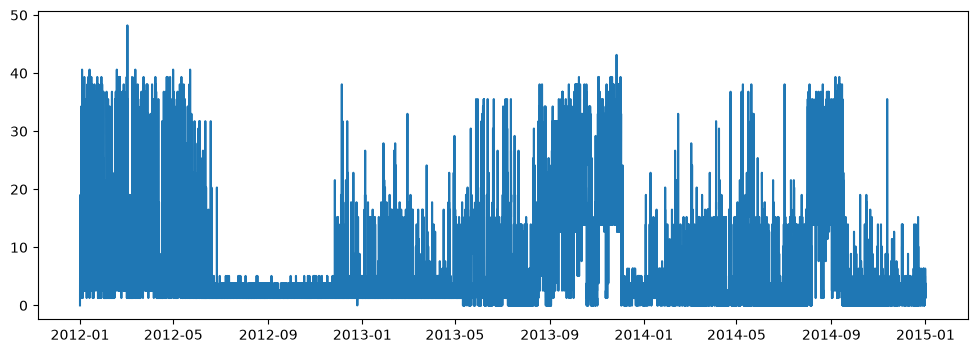

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], df["load"])
plt.show()

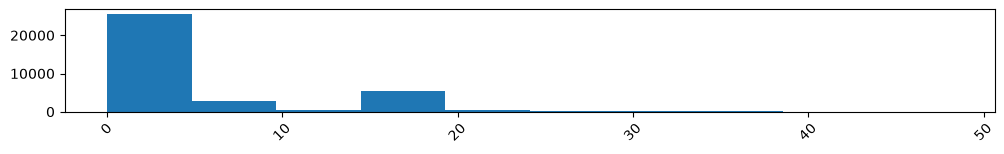

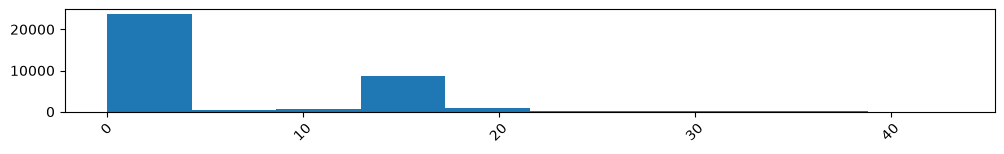

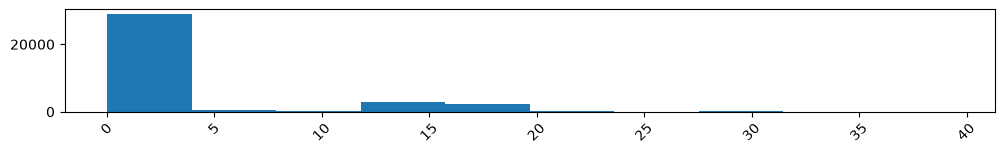

In [8]:
for year in [2012, 2013, 2014]:
    yearly = df.loc[df["timestamp"].dt.year == year]
    plt.figure(figsize=(12, 4/3))
    plt.hist(yearly["load"])
    plt.xticks(rotation=45)
    plt.show()

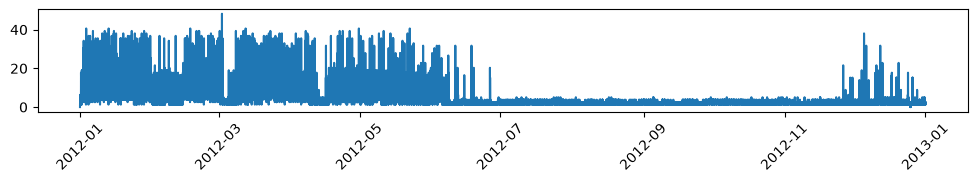

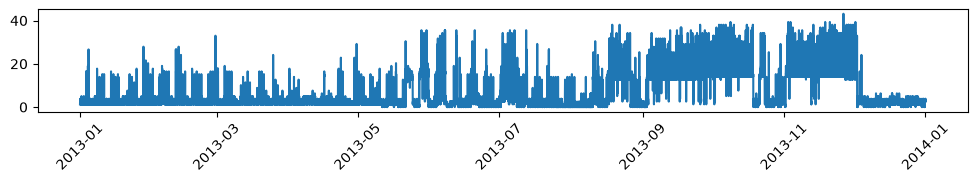

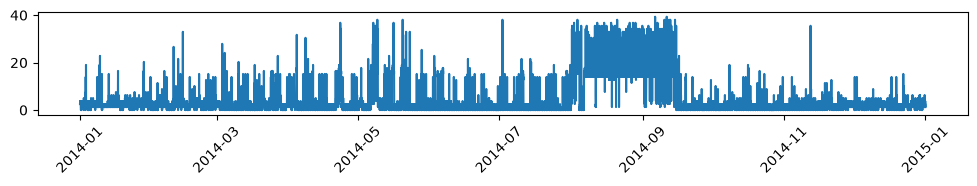

In [9]:
for year in [2012, 2013, 2014]:
    yearly = df.loc[df["timestamp"].dt.year == year]
    plt.figure(figsize=(12, 4/3))
    plt.plot(yearly["timestamp"], yearly["load"])
    plt.xticks(rotation=45)
    plt.show()

# Daily patterns

In [10]:
df["timestamp"].head()

35039   2012-01-01 00:00:00
35040   2012-01-01 00:15:00
35041   2012-01-01 00:30:00
35042   2012-01-01 00:45:00
35043   2012-01-01 01:00:00
Name: timestamp, dtype: datetime64[us]

In [11]:
df["time_of_day"] = (
    df["timestamp"].dt.hour * 60 # dt.hour extract the hour
    + df["timestamp"].dt.minute  # dt.minute extract the minute
)

daily_pattern = df.groupby("time_of_day")["load"].mean()
daily_pattern

time_of_day
0       4.761486
15      4.728778
30      4.853829
45      4.873513
60      4.931407
          ...   
1365    5.459400
1380    5.510347
1395    5.541610
1410    5.400348
1425    4.989301
Name: load, Length: 96, dtype: float64

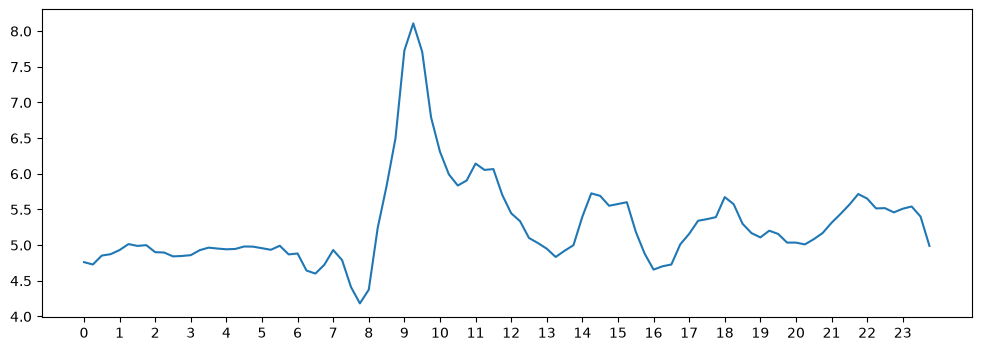

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(daily_pattern.index / 60, daily_pattern.values)
plt.xticks(range(24))
plt.show()

In [13]:
df["year"] = df["timestamp"].dt.year

daily_pattern = (
    df.groupby(["year", "time_of_day"])["load"]
      .mean()
      .reset_index()
)

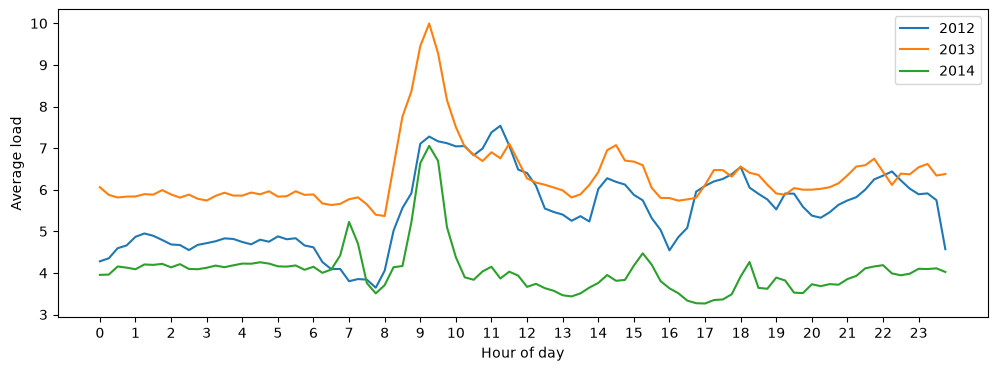

In [14]:
plt.figure(figsize=(12, 4))
for year in [2012, 2013, 2014]:
    yearly = daily_pattern[daily_pattern["year"] == year]

    plt.plot(
        yearly["time_of_day"] / 60,
        yearly["load"],
        label=str(year)
    )

plt.xlabel("Hour of day")
plt.ylabel("Average load")
plt.xticks(range(24))
plt.legend()
plt.show()

# Weekly patterns

In [15]:
df["day_of_week"] = df["timestamp"].dt.dayofweek

weekly_pattern = df.groupby("day_of_week")["load"].mean()
weekly_pattern

day_of_week
0    5.206060
1    5.589246
2    5.692389
3    5.474384
4    5.536439
5    4.798202
6    4.754673
Name: load, dtype: float64

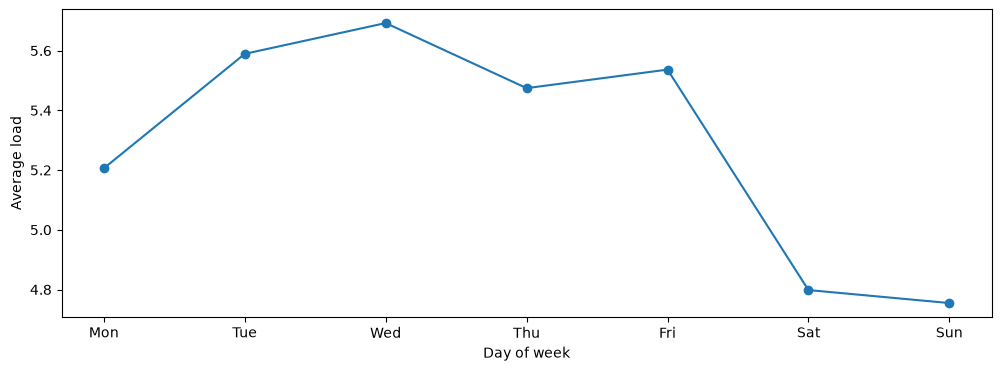

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(
    weekly_pattern.index,
    weekly_pattern.values,
    marker="o"
)

plt.xlabel("Day of week")
plt.ylabel("Average load")
plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)
plt.show()

In [17]:
weekly_pattern = (
    df.groupby(["year", "day_of_week"])["load"]
      .mean()
      .reset_index()
)

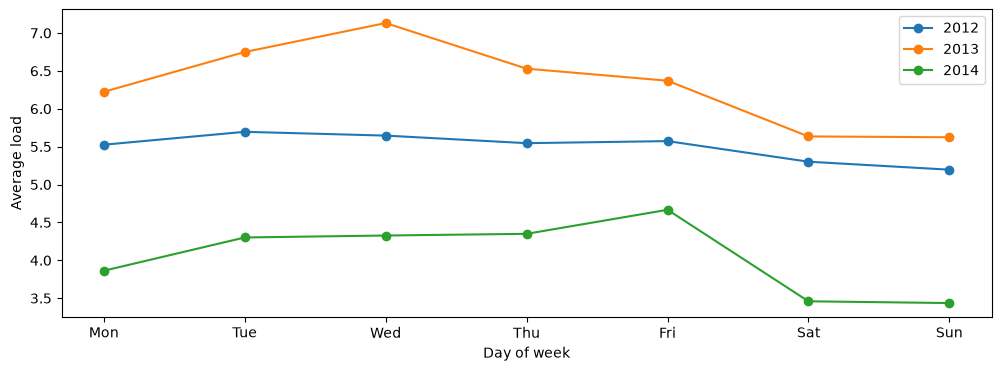

In [18]:
plt.figure(figsize=(12, 4))
for year in [2012, 2013, 2014]:
    yearly = weekly_pattern[weekly_pattern["year"] == year]

    plt.plot(
        yearly["day_of_week"],
        yearly["load"],
        marker="o",
        label=str(year)
    )

plt.xlabel("Day of week")
plt.ylabel("Average load")
plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)
plt.legend()
plt.show()

In [19]:
weekly_pattern = (
    df
    .groupby(["day_of_week", "time_of_day"])["load"]
    .mean()
    .reset_index()
)

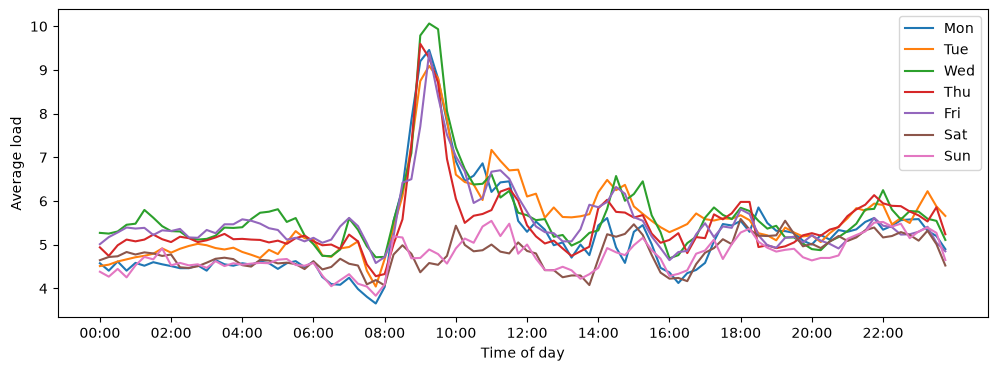

In [20]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(12, 4))
for day in range(7):
    temp = weekly_pattern[
        weekly_pattern["day_of_week"] == day
    ]

    plt.plot(
        temp["time_of_day"],
        temp["load"],
        label=day_names[day]
    )

plt.xlabel("Time of day")
plt.ylabel("Average load")
plt.xticks(
    range(0, 1440, 120),
    [f"{h:02d}:00" for h in range(0, 24, 2)]
)
plt.legend()
plt.show()

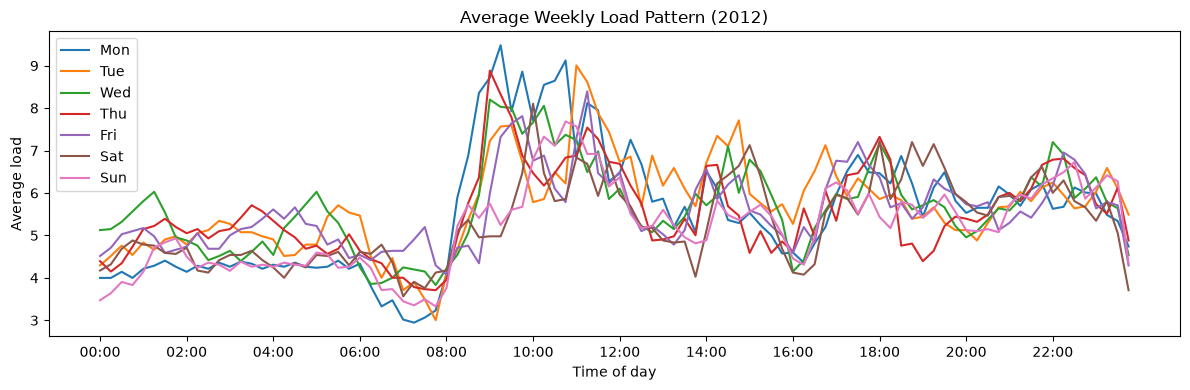

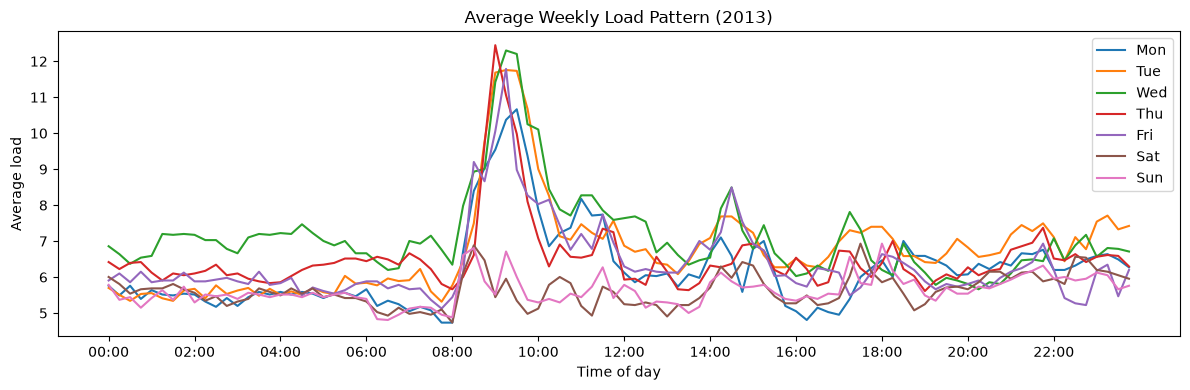

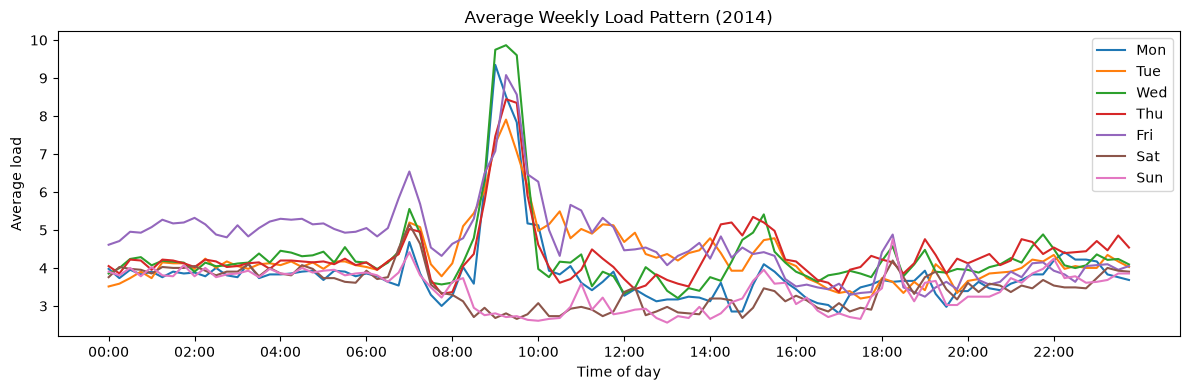

In [21]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

for year in [2012, 2013, 2014]:

    weekly_pattern = (
        df[df["year"] == year]
        .groupby(["day_of_week", "time_of_day"])["load"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 4))

    for day in range(7):
        temp = weekly_pattern[
            weekly_pattern["day_of_week"] == day
        ]

        plt.plot(
            temp["time_of_day"],
            temp["load"],
            label=day_names[day]
        )

    plt.xlabel("Time of day")
    plt.ylabel("Average load")
    plt.title(f"Average Weekly Load Pattern ({year})")
    plt.xticks(
        range(0, 1440, 120),
        [f"{h:02d}:00" for h in range(0, 24, 2)]
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

# Monthly patterns

In [22]:
df["month"] = df["timestamp"].dt.month

monthly_pattern = df.groupby("month")["load"].mean()

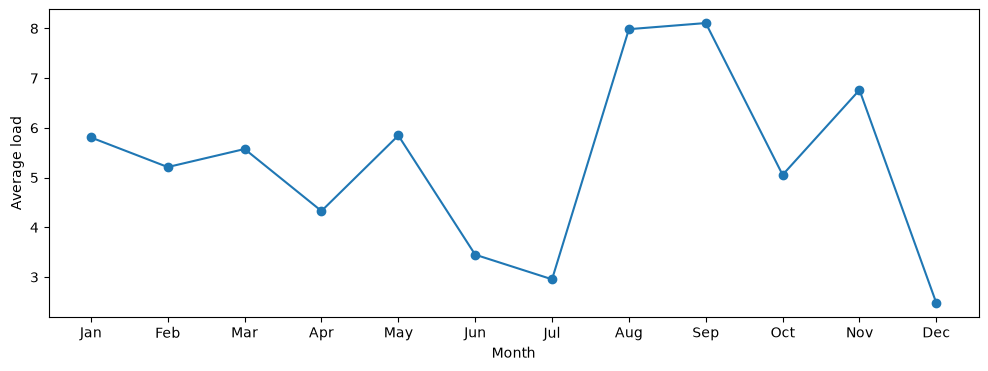

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average load")
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.show()

In [24]:
monthly_pattern = (
    df.groupby(["year", "month"])["load"]
      .mean()
      .reset_index()
)

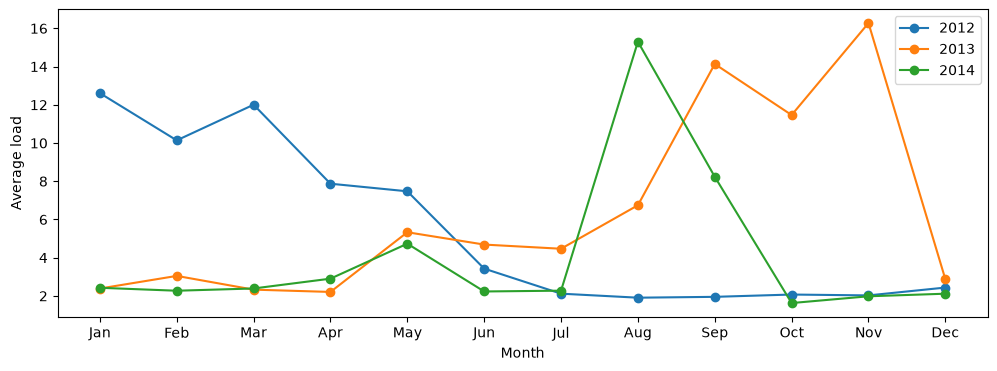

In [25]:
plt.figure(figsize=(12, 4))
for year in [2012, 2013, 2014]:
    yearly = monthly_pattern[monthly_pattern["year"] == year]

    plt.plot(
        yearly["month"],
        yearly["load"],
        marker="o",
        label=str(year)
    )

plt.xlabel("Month")
plt.ylabel("Average load")
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.legend()
plt.show()

# Check lag correlation

In [26]:
df["lag_1"] = df["load"].shift(1)
df["lag_4"] = df["load"].shift(4)
df["lag_96"] = df["load"].shift(96)
df["lag_672"] = df["load"].shift(672)
# 1   = 15 minutes
# 4   = 1 hour
# 96  = 1 day
# 672 = 1 week

In [27]:
df[["load", "lag_1", "lag_4", "lag_96", "lag_672"]].corr()

,load,lag_1,lag_4,lag_96,lag_672
load,1.000000,0.900595,0.767325,0.685188,0.532879
lag_1,0.900595,1.000000,0.794142,0.680010,0.527492
lag_4,0.767325,0.794142,1.000000,0.652273,0.505800
lag_96,0.685188,0.680010,0.652273,1.000000,0.539550
lag_672,0.532879,0.527492,0.505800,0.539550,1.000000


In [28]:
for lag in range(1, 26):
    df[f"lag_{lag}"] = df["load"].shift(lag)

df[["load"] + [f"lag_{i}" for i in range(1, 26)]].corr()["load"]

load      1.000000
lag_1     0.900595
lag_2     0.835439
lag_3     0.794142
lag_4     0.767325
lag_5     0.745938
lag_6     0.733171
lag_7     0.723142
lag_8     0.717674
lag_9     0.714809
lag_10    0.713973
lag_11    0.711996
lag_12    0.711103
lag_13    0.711439
lag_14    0.710503
lag_15    0.706842
lag_16    0.703818
lag_17    0.698751
lag_18    0.694225
lag_19    0.691615
lag_20    0.688880
lag_21    0.687741
lag_22    0.685631
lag_23    0.684927
lag_24    0.681683
lag_25    0.678869
Name: load, dtype: float64

# Plot ACF plots

In [29]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose

<Figure size 1200x400 with 0 Axes>

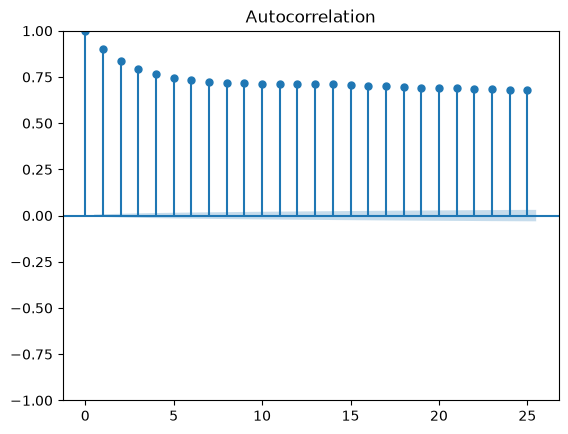

In [30]:
plt.figure(figsize=(12, 4))
plot_acf(
    df["load"].dropna(),
    lags=25
)
plt.show()

<Figure size 1200x400 with 0 Axes>

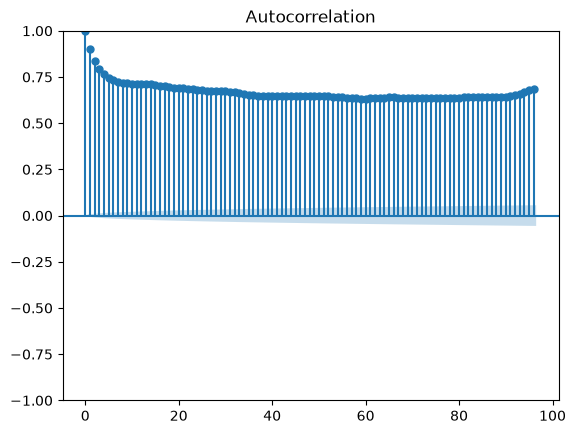

In [31]:
plt.figure(figsize=(12, 4))
plot_acf(
    df["load"].dropna(),
    lags=96
)
plt.show()

<Figure size 1200x400 with 0 Axes>

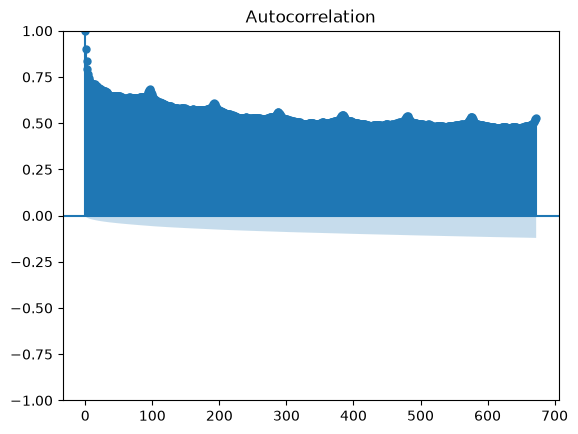

In [32]:
plt.figure(figsize=(12, 4))
plot_acf(
    df["load"].dropna(),
    lags=672
)
plt.show()

# Plot decomposition plots

<Figure size 2400x1200 with 0 Axes>

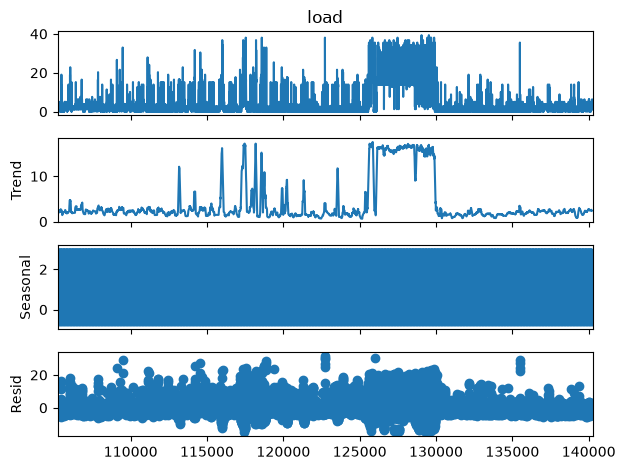

In [33]:
plt.figure(figsize=(24, 12))
for year in [2014]: #for year in [2012, 2013, 2014]:
    
    result = seasonal_decompose(
        df[df["year"] == year]["load"].dropna(),
        model="additive",
        period=96
    )
    
    result.plot()
    plt.show()
    # observed data
    # Trend: Trend after accounting for daily cycle
    # Seasonal: Daily repeating pattern
    # Residual: What's left

In [34]:
print(result.seasonal.describe())

count    3.504000e+04
mean    -7.452182e-18
std      6.114419e-01
min     -7.961601e-01
25%     -3.289923e-01
50%     -2.822549e-02
75%      1.138755e-01
max      3.006316e+00
Name: seasonal, dtype: float64


In [35]:
# result.seasonal.iloc[:96].plot(figsize=(12, 4))
# plt.title("2014 Daily Seasonal Component — First Day")
# plt.xlabel("15-minute observations")
# plt.ylabel("Seasonal effect")
# plt.show()

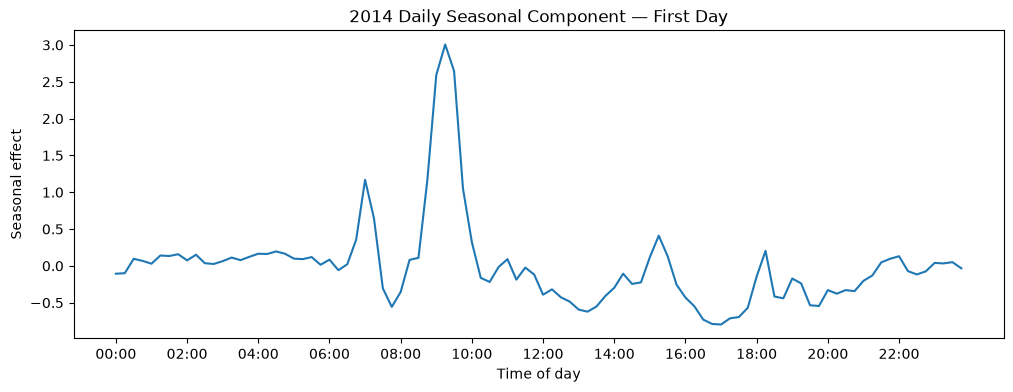

In [36]:
seasonal_day = result.seasonal.iloc[:96]

plt.figure(figsize=(12, 4))
plt.plot(range(96), seasonal_day.values)
plt.title("2014 Daily Seasonal Component — First Day")
plt.xlabel("Time of day")
plt.ylabel("Seasonal effect")
plt.xticks(
    range(0, 96, 8),
    [f"{h:02d}:00" for h in range(0, 24, 2)]
)
plt.show()

<Figure size 2400x1200 with 0 Axes>

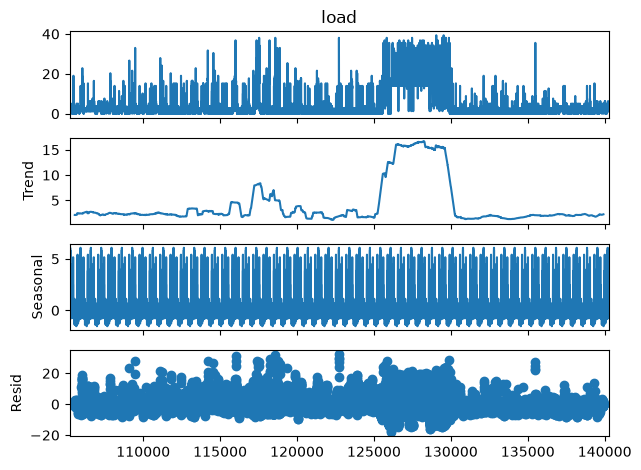

In [37]:
plt.figure(figsize=(24, 12))
for year in [2014]: #for year in [2012, 2013, 2014]:
    
    result = seasonal_decompose(
        df[df["year"] == year]["load"].dropna(),
        model="additive",
        period=672
    )
    
    result.plot()
    plt.show()
    # observed data
    # Trend: Trend after accounting for weekly cycle
    # Seasonal: Weekly repeating pattern
    # Residual: What's left

In [38]:
print(result.seasonal.describe())

count    35040.000000
mean         0.000859
std          0.978517
min         -1.536585
25%         -0.490960
50%         -0.117103
75%          0.232333
max          6.079258
Name: seasonal, dtype: float64


In [39]:
# result.seasonal.iloc[:672].plot(figsize=(12, 4))
# plt.title("2014 Weekly Seasonal Component — A Week")
# plt.xlabel("15-minute observations")
# plt.ylabel("Seasonal effect")
# plt.show()

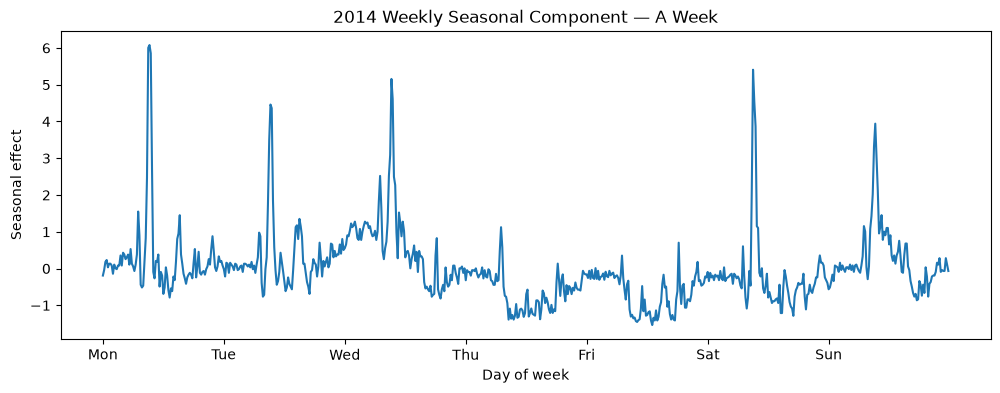

In [40]:
seasonal_week = result.seasonal.iloc[:672]

plt.figure(figsize=(12, 4))
plt.plot(range(672), seasonal_week.values)
plt.title("2014 Weekly Seasonal Component — A Week")
plt.xlabel("Day of week")
plt.ylabel("Seasonal effect")
plt.xticks(
    range(0, 672, 96),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)
plt.show()

<Figure size 2400x1200 with 0 Axes>

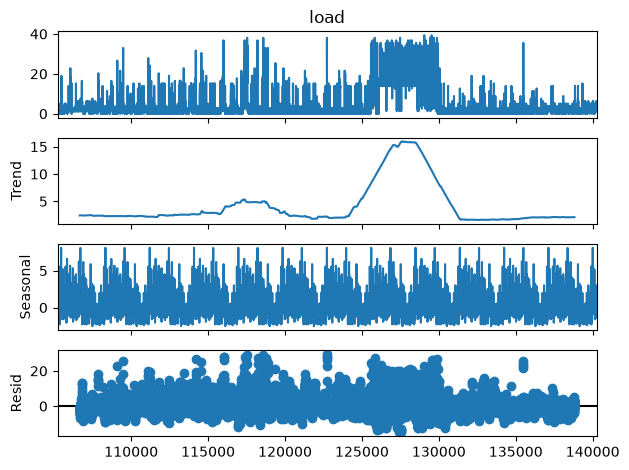

In [41]:
plt.figure(figsize=(24, 12))
for year in [2014]:

    result = seasonal_decompose(
        df[df["year"] == year]["load"].dropna(),
        model="additive",
        period=2880
    )

    result.plot()
    plt.show()

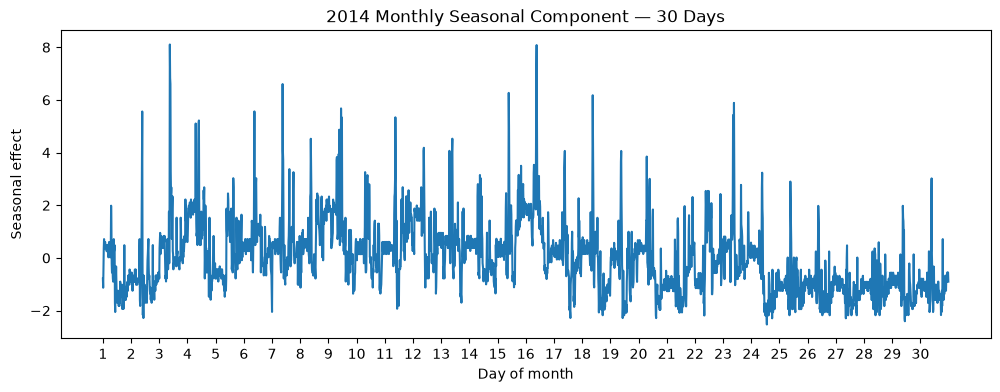

In [42]:
seasonal_month = result.seasonal.iloc[:2880]

plt.figure(figsize=(12, 4))
plt.plot(range(2880), seasonal_month.values)
plt.title("2014 Monthly Seasonal Component — 30 Days")
plt.xlabel("Day of month")
plt.ylabel("Seasonal effect")
plt.xticks(
    range(0, 2880, 96),
    range(1, 31)
)
plt.show()